<a href="https://colab.research.google.com/github/he380801-sketch/eeg-classification-ml-comparison/blob/main/Multilayer_Perceptron_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# 1. IMPORTACIONES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer


In [ ]:
file_id = '1k2BqAKd_bqT_eV-TB5isdfiDnJbYXVwo'
url = f'https://drive.google.com/uc?id={file_id}'

# Si tu archivo es un CSV:
try:
    df = pd.read_csv(url)
    print("¡Base de datos CSV cargada exitosamente!")
    print(df.head())
except Exception as e:
    print(f"Error al cargar la base de datos CSV: {e}")

¡Base de datos CSV cargada exitosamente!
   Grupo Participante  Minuto        C3        C4        CZ       EMG  \
0      0          EMV       1  1.457191  1.465362  1.389850  1.469966   
1      0          EMV      10  1.442564  1.372664  1.361794  1.310307   
2      0          EMV      11  1.445738  1.397893  1.363018  1.246467   
3      0          EMV      12  1.381500  1.422462  1.443394  1.445102   
4      0          EMV      13  1.443665  1.355041  1.360214  1.301061   

         F3        F4        F7  ...        O1        O2        P3        P4  \
0  1.471585  1.383370  1.416681  ...  1.419505  1.460171  1.435626  1.401177   
1  1.477391  1.366440  1.439025  ...  1.417780  1.421081  1.410483  1.395753   
2  1.451693  1.372738  1.398308  ...  1.444138  1.434578  1.425999  1.411785   
3  1.422085  1.413301  1.450779  ...  1.427840  1.451817  1.403597  1.434047   
4  1.474152  1.365256  1.433039  ...  1.415445  1.402281  1.391482  1.395755   

         PZ       ROG        T3        

In [ ]:
# ============================================
# 3. PREPARAR DATOS
# ============================================
X = df.drop(columns=["Grupo", "Participante", "Minuto"])
y = df["Grupo"]
groups = df["Participante"]

# Convertir etiquetas a números
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# ============================================
# 4. LOPO CROSS-VALIDATION
# ============================================
logo = LeaveOneGroupOut()

patient_accuracies = []
patient_predictions = []
patient_true = []

all_preds = []
all_true = []


In [ ]:
# ============================================
# 5. LOOP PRINCIPAL
# ============================================
for train_idx, test_idx in logo.split(X, y, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # -------------------------
    # IMPUTACIÓN (NaN)
    # -------------------------
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # -------------------------
    # ESCALADO
    # -------------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # -------------------------
    # MODELO MLP
    # -------------------------
    model = MLPClassifier(
        hidden_layer_sizes=(30,),
        activation='relu',
        solver='adam',
        alpha=0.001,
        max_iter=500,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predicciones por cut
    y_pred = model.predict(X_test)

    # -------------------------
    # Patient Accuracy
    # -------------------------
    acc = accuracy_score(y_test, y_pred)
    patient_accuracies.append(acc)

    # -------------------------
    # Majority Vote
    # -------------------------
    majority_pred = np.bincount(y_pred).argmax()
    true_label = y_test[0]

    patient_predictions.append(majority_pred)
    patient_true.append(true_label)

    # -------------------------
    # Micro Accuracy
    # -------------------------
    all_preds.extend(y_pred)
    all_true.extend(y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [ ]:
# ============================================
# 6. MÉTRICAS FINALES
# ============================================
mean_acc = np.mean(patient_accuracies)
std_acc = np.std(patient_accuracies)

patient_level_acc = accuracy_score(patient_true, patient_predictions)

cm = confusion_matrix(patient_true, patient_predictions)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

micro_acc = accuracy_score(all_true, all_preds)

print("===== RESULTADOS MLP =====")
print("Mean Patient Accuracy:", mean_acc)
print("Std Dev:", std_acc)
print("Patient-Level Accuracy:", patient_level_acc)
print("Micro Accuracy:", micro_acc)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

===== RESULTADOS MLP =====
Mean Patient Accuracy: 0.5411111111111112
Std Dev: 0.208323703481142
Patient-Level Accuracy: 0.5
Micro Accuracy: 0.5411111111111111
Sensitivity: 0.5
Specificity: 0.5


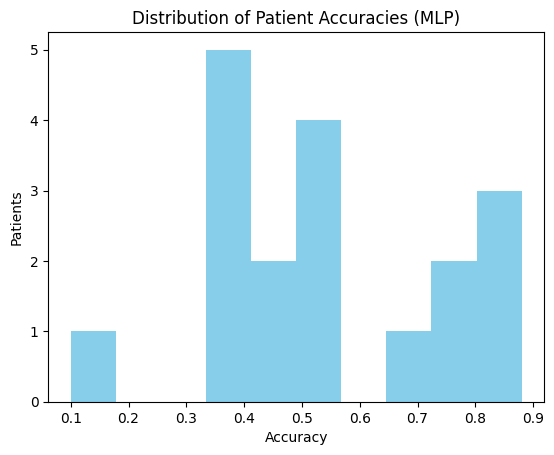

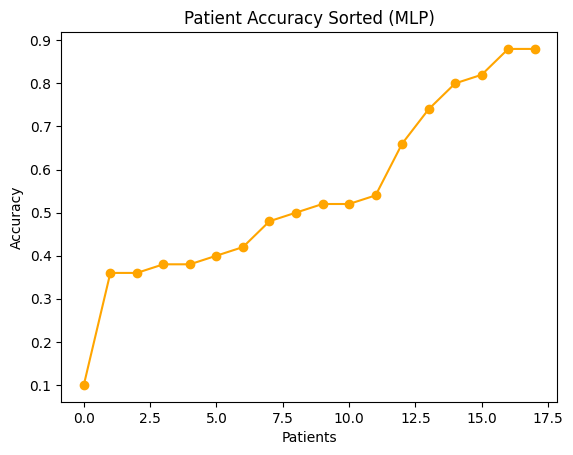

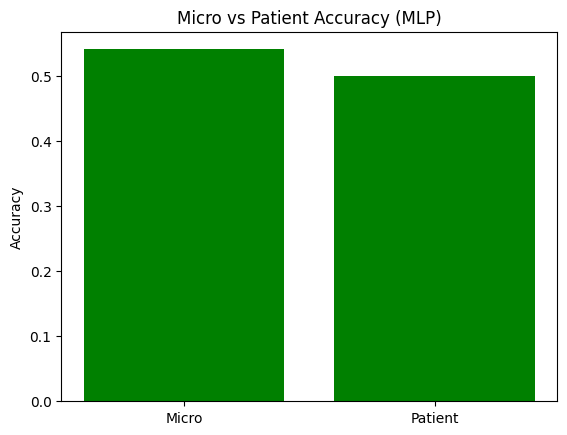

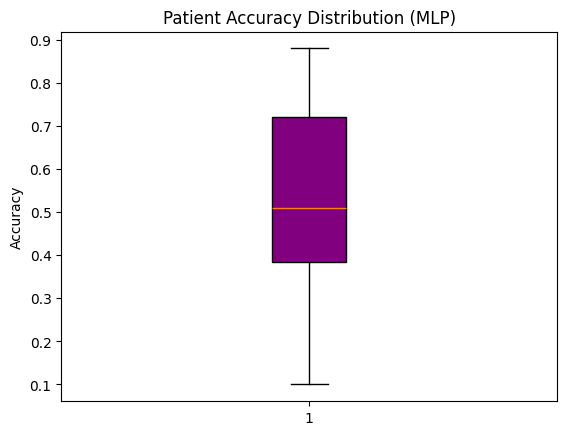

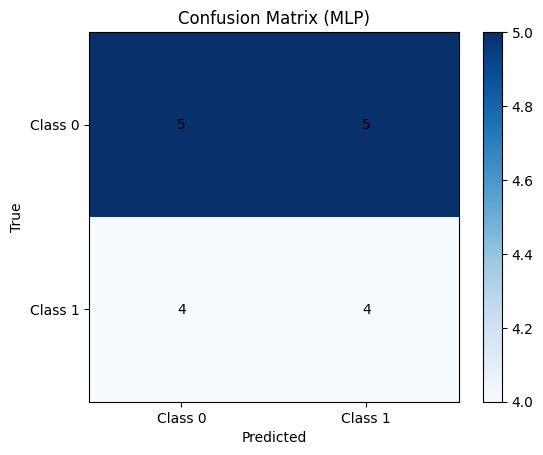

In [ ]:
# ============================================
# 7. GRÁFICAS (COLORES PERSONALIZADOS)
# ============================================

color_hist = "skyblue"
color_line = "orange"
color_bar = "green"
color_box = "purple"
cmap_cm = "Blues"


# Histograma
plt.figure()
plt.hist(patient_accuracies, bins=10, color=color_hist)
plt.title("Distribution of Patient Accuracies (MLP)")
plt.xlabel("Accuracy")
plt.ylabel("Patients")
plt.show()


# Línea ordenada
plt.figure()
plt.plot(sorted(patient_accuracies), marker='o', color=color_line)
plt.title("Patient Accuracy Sorted (MLP)")
plt.xlabel("Patients")
plt.ylabel("Accuracy")
plt.show()


# Barras comparación
plt.figure()
plt.bar(["Micro", "Patient"], [micro_acc, patient_level_acc], color=color_bar)
plt.title("Micro vs Patient Accuracy (MLP)")
plt.ylabel("Accuracy")
plt.show()


# Boxplot
plt.figure()
box = plt.boxplot(patient_accuracies, patch_artist=True)
for patch in box['boxes']:
    patch.set_facecolor(color_box)

plt.title("Patient Accuracy Distribution (MLP)")
plt.ylabel("Accuracy")
plt.show()


# Confusion Matrix
plt.figure()
plt.imshow(cm, cmap=cmap_cm)
plt.title("Confusion Matrix (MLP)")
plt.colorbar()

plt.xticks([0,1], ["Class 0", "Class 1"])
plt.yticks([0,1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [ ]:
# ============================================
# COMPARACIÓN DE ACTIVACIONES MLP
# ============================================

activations = ["relu", "tanh", "logistic"]

results = {}

for act in activations:

    patient_accuracies = []
    patient_predictions = []
    patient_true = []

    all_preds = []
    all_true = []

    for train_idx, test_idx in logo.split(X, y, groups):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Imputación
        imputer = SimpleImputer(strategy="mean")
        X_train = imputer.fit_transform(X_train)
        X_test = imputer.transform(X_test)

        # Escalado
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Modelo con activación variable
        model = MLPClassifier(
            hidden_layer_sizes=(30,),
            activation=act,
            max_iter=500,
            alpha=0.001,
            random_state=42
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Métricas
        acc = accuracy_score(y_test, y_pred)
        patient_accuracies.append(acc)

        majority_pred = np.bincount(y_pred).argmax()
        true_label = y_test[0]

        patient_predictions.append(majority_pred)
        patient_true.append(true_label)

        all_preds.extend(y_pred)
        all_true.extend(y_test)

    # Resultados
    mean_acc = np.mean(patient_accuracies)
    patient_acc = accuracy_score(patient_true, patient_predictions)

    results[act] = (mean_acc, patient_acc)

# Mostrar resultados
for act, (mean_acc, patient_acc) in results.items():
    print(f"Activation: {act}")
    print(f"Mean Patient Accuracy: {mean_acc}")
    print(f"Patient-Level Accuracy: {patient_acc}")
    print("-----------------------------")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Activation: relu
Mean Patient Accuracy: 0.5411111111111112
Patient-Level Accuracy: 0.5
-----------------------------
Activation: tanh
Mean Patient Accuracy: 0.5822222222222222
Patient-Level Accuracy: 0.5
-----------------------------
Activation: logistic
Mean Patient Accuracy: 0.6222222222222222
Patient-Level Accuracy: 0.7222222222222222
-----------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


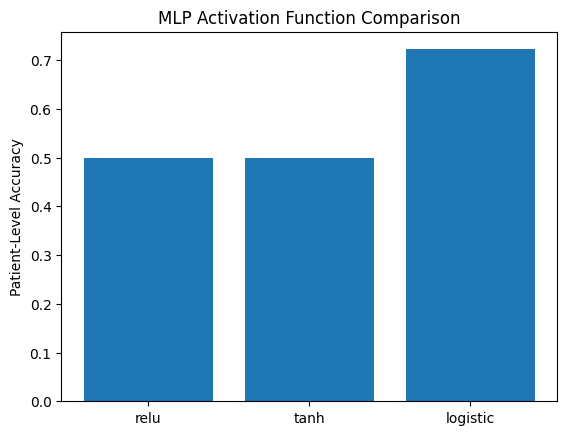

In [ ]:
plt.figure()

labels = list(results.keys())
values = [v[1] for v in results.values()]  # patient-level

plt.bar(labels, values)

plt.title("MLP Activation Function Comparison")
plt.ylabel("Patient-Level Accuracy")

plt.show()